In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split   # for splitting dataset
from sklearn.tree import DecisionTreeClassifier        # classification model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

## Decision Tree Classification Model

**Load and Inspect Data**

In [15]:
# Load the CSV
bank = pd.read_csv("BankSet.csv")

# Quick look at data
bank.head()
bank.info()
bank.describe()
bank['purchase'].value_counts()   # Check balance of classes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  campaign   4521 non-null   int64 
 12  pdays      4521 non-null   int64 
 13  previous   4521 non-null   int64 
 14  poutcome   4521 non-null   object
 15  purchase   4521 non-null   object
dtypes: int64(6), object(10)
memory usage: 565.3+ KB


purchase
no     4000
yes     521
Name: count, dtype: int64

**Preprocess the Data**

In [16]:
# Select categorical columns
categorical_cols = ['job','marital','education','default','housing','loan','contact','month','poutcome']

# Create dummy variables
bank_dummies = pd.get_dummies(bank, columns=categorical_cols, drop_first=True)

# Convert target to 0/1
bank_dummies['purchase'] = bank_dummies['purchase'].map({'no':0,'yes':1})


**Split into train/test sets**

In [17]:
X = bank_dummies.drop('purchase', axis=1)   # Features
y = bank_dummies['purchase']                # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Build a classification model(Decision Tree)**

In [18]:
# Create model
class_tree = DecisionTreeClassifier(random_state=42)

# Fit model
class_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


**Evaluate the Model**

Confusion Matrix

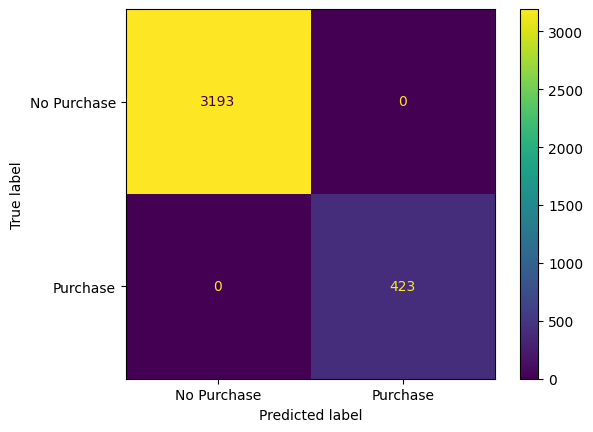

In [19]:
# Generate predictions
y_train_pred = class_tree.predict(X_train)
y_test_pred = class_tree.predict(X_test)

# Confusion matrix
cm_train = confusion_matrix(y_train, y_train_pred)
cmd_train = ConfusionMatrixDisplay(cm_train, display_labels=['No Purchase','Purchase'])
cmd_train.plot()

Accuracy

In [20]:
accuracy_train = round(accuracy_score(y_train, y_train_pred), 3)
accuracy_test = round(accuracy_score(y_test, y_test_pred), 3)
print("Training Accuracy:", accuracy_train)
print("Test Accuracy:", accuracy_test)

Training Accuracy: 1.0
Test Accuracy: 0.808


 **Identify important features**

In [21]:
importances = pd.Series(class_tree.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances.head(10))  # Top 10 most important predictors

balance                0.194016
age                    0.161213
day                    0.133275
poutcome_success       0.086328
campaign               0.057844
pdays                  0.051299
education_secondary    0.024107
job_technician         0.021672
previous               0.019148
housing_yes            0.016639
dtype: float64


## Logistic Regression Model

In [22]:
from sklearn.linear_model import LogisticRegression

**Build the Model**

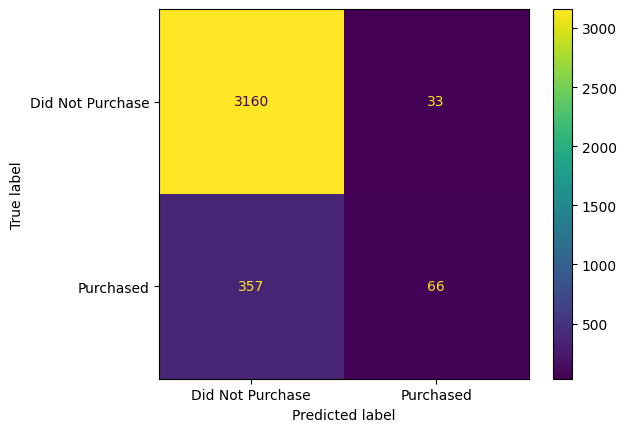

In [23]:
#Train the logistic regression model
log_model = LogisticRegression(max_iter=10000)  # increase max_iter to ensure convergence
log_model.fit(X_train, y_train)

#Make predictions on training set
y_train_pred = log_model.predict(X_train)

#Generate and display confusion matrix
cm = confusion_matrix(y_train, y_train_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels=['Did Not Purchase', 'Purchased'])
cmd.plot()

**Accuracy**

In [24]:
#Calculate and display accuracy
accuracy = accuracy_score(y_train, y_train_pred)
print("Training Accuracy:", round(accuracy, 3))

Training Accuracy: 0.892


**Identify Important Features**

In [25]:
#define important features
feature_importances = pd.Series(
    log_model.coef_[0],
    index=X_train.columns
).sort_values(ascending=False)

In [26]:
# Display top 5 positive and top 5 negative features
top_positive = feature_importances.head(5)
top_negative = feature_importances.tail(5)

print("Top 5 Positive Features (increase purchase likelihood):\n", top_positive.round(3))
print("\nTop 5 Negative Features (decrease purchase likelihood):\n", top_negative.round(3))

Top 5 Positive Features (increase purchase likelihood):
 poutcome_success    2.310
month_oct           0.942
month_mar           0.685
poutcome_other      0.625
default_yes         0.541
dtype: float64

Top 5 Negative Features (decrease purchase likelihood):
 month_jul         -0.650
month_may         -0.665
month_nov         -0.726
month_jan         -0.923
contact_unknown   -1.005
dtype: float64
